In [1]:
#Imports
import numpy as np
import pickle

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [2]:
#Load Dataset
X = np.load('../data/X.npy')
y = np.load('../data/y.npy')

In [3]:
#Recreating same split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
#Load scalar + Transform
scaler = pickle.load(open('../models/scaler.pkl', 'rb'))

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
# Load Model
model = pickle.load(open('../models/model.pkl', 'rb'))
print(model)

LogisticRegression(C=10, max_iter=1000)


In [6]:
#Prediction
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [7]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        47

    accuracy                           1.00        77
   macro avg       1.00      1.00      1.00        77
weighted avg       1.00      1.00      1.00        77



In [8]:
# Confusion Matrics
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[30  0]
 [ 0 47]]


In [9]:
#ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


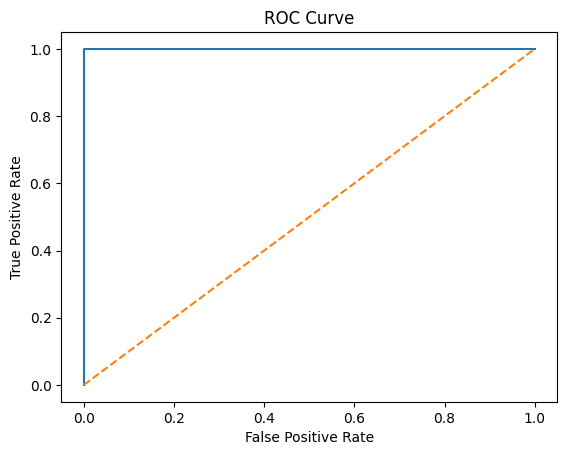

In [10]:
#ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [13]:
feature_names = pickle.load(open('../models/features.pkl', 'rb'))

In [18]:
import pandas as pd

X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_train_df = pd.DataFrame(X_train, columns=feature_names)

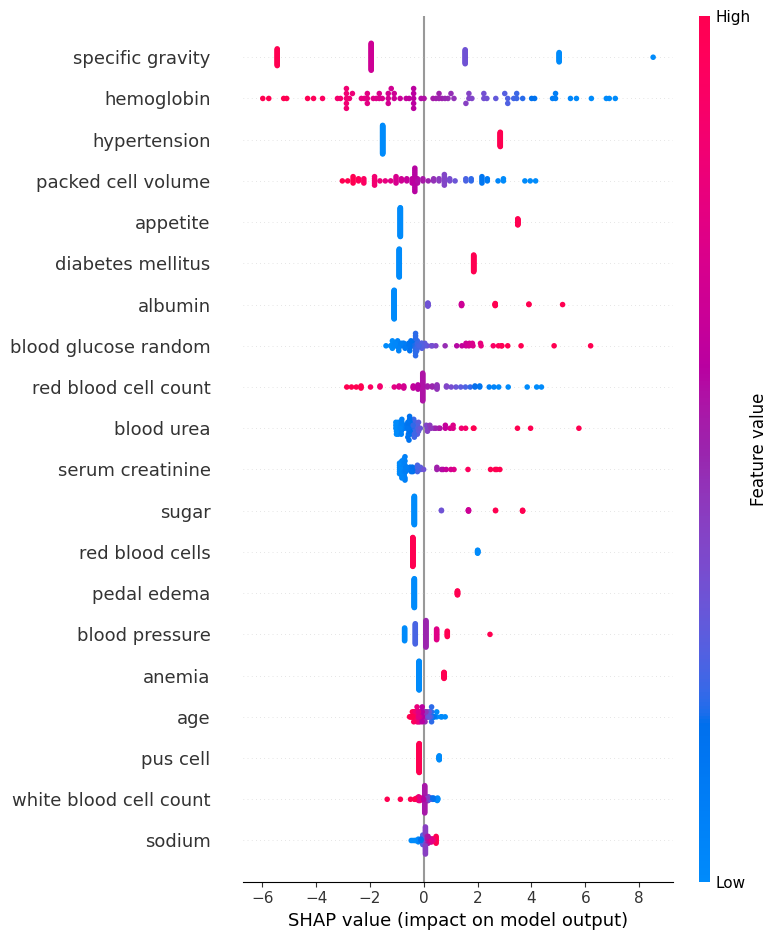

In [21]:
import shap

explainer = shap.Explainer(model, X_train_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

In [22]:
print("Duplicates:", pd.DataFrame(X).duplicated().sum())

Duplicates: 0


In [23]:
import numpy as np

train_set = set(map(tuple, X_train))
test_set = set(map(tuple, X_test))

print("Overlap:", len(train_set & test_set))

Overlap: 0


In [24]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

print("Dummy score:", dummy.score(X_test, y_test))

Dummy score: 0.6103896103896104
